### The data set has information about features of silhouette extracted from the images of different cars

Four "Corgie" model vehicles were used for the experiment: a double decker bus, Cheverolet van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.



### 1. Read the dataset using function .dropna() - to avoid dealing with NAs as of now

In [1]:
import numpy as np
import pandas as pd
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [29]:
veh_df = pd.read_csv("vehicle.csv")
veh_df.dropna(inplace=True)
veh_df.head(3).T

,0,1,2
compactness,95,91,104
circularity,48,41,50
distance_circularity,83,84,106
radius_ratio,178,141,209
pr.axis_aspect_ratio,72,57,66
max.length_aspect_ratio,10,9,10
scatter_ratio,162,149,207
elongatedness,42,45,32
pr.axis_rectangularity,20,19,23
max.length_rectangularity,159,143,158


In [30]:
veh_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 813 entries, 0 to 845
Data columns (total 19 columns):
compactness                    813 non-null int64
circularity                    813 non-null float64
distance_circularity           813 non-null float64
radius_ratio                   813 non-null float64
pr.axis_aspect_ratio           813 non-null float64
max.length_aspect_ratio        813 non-null int64
scatter_ratio                  813 non-null float64
elongatedness                  813 non-null float64
pr.axis_rectangularity         813 non-null float64
max.length_rectangularity      813 non-null int64
scaled_variance                813 non-null float64
scaled_variance.1              813 non-null float64
scaled_radius_of_gyration      813 non-null float64
scaled_radius_of_gyration.1    813 non-null float64
skewness_about                 813 non-null float64
skewness_about.1               813 non-null float64
skewness_about.2               813 non-null float64
hollows_ratio    

In [31]:
veh_df.describe().transpose()   #class is not present

,count,mean,std,min,25%,50%,75%,max
compactness,813.0,93.656827,8.233751,73.0,87.0,93.0,100.0,119.0
circularity,813.0,44.803198,6.146659,33.0,40.0,44.0,49.0,59.0
distance_circularity,813.0,82.043050,15.783070,40.0,70.0,79.0,98.0,112.0
radius_ratio,813.0,169.098401,33.615402,104.0,141.0,167.0,195.0,333.0
pr.axis_aspect_ratio,813.0,61.774908,7.973000,47.0,57.0,61.0,65.0,138.0
max.length_aspect_ratio,813.0,8.599016,4.677174,2.0,7.0,8.0,10.0,55.0
scatter_ratio,813.0,168.563346,33.082186,112.0,146.0,157.0,198.0,265.0
elongatedness,813.0,40.988930,7.803380,26.0,33.0,43.0,46.0,61.0
pr.axis_rectangularity,813.0,20.558426,2.573184,17.0,19.0,20.0,23.0,29.0
max.length_rectangularity,813.0,147.891759,14.504648,118.0,137.0,146.0,159.0,188.0


### 2. Print/ Plot the dependent (categorical variable) - Class column

Since the variable is categorical, you can use value_counts function

In [32]:
# Let us look at the target column which is 'class' to understand how the data is distributed amongst the various values
veh_df.groupby(["class"]).count()

# Most are not diabetic. The ratio is almost 1:2 in favor or class 0.  The model's ability to predict class 0 will 
# be better than predicting class 1.

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
class,,,,,,,,,,,,,,,,,,
bus,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205
car,413,413,413,413,413,413,413,413,413,413,413,413,413,413,413,413,413,413
van,195,195,195,195,195,195,195,195,195,195,195,195,195,195,195,195,195,195


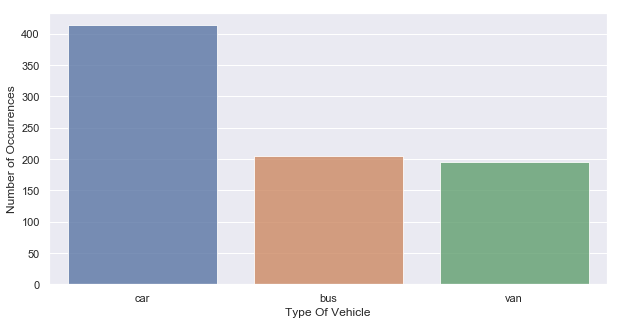

In [33]:
class_count  = veh_df['class'].value_counts()
class_count = class_count[:10,]
plt.figure(figsize=(10,5))
sns.barplot(class_count.index, class_count.values, alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Type Of Vehicle', fontsize=12)
plt.show()

### Check for any missing values in the data 

In [34]:
veh_df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

### 3. Standardize the data 

In [47]:
from scipy.stats import zscore
veh_df_attr = veh_df.loc[:, 'compactness':'hollows_ratio']
veh_df_attr_Z = veh_df_attr.apply(zscore)
veh_df_attr_Z.head(3).T

,0,1,2
compactness,0.163231,-0.322874,1.256966
circularity,0.520408,-0.619123,0.845988
distance_circularity,0.060669,0.124067,1.518823
radius_ratio,0.264970,-0.836393,1.187734
pr.axis_aspect_ratio,1.283254,-0.599253,0.530251
max.length_aspect_ratio,0.299721,0.085785,0.299721
scatter_ratio,-0.198517,-0.591720,1.162569
elongatedness,0.129648,0.514333,-1.152637
pr.axis_rectangularity,-0.217151,-0.606014,0.949438
max.length_rectangularity,0.766312,-0.337462,0.697326


Since the dimensions of the data are not really known to us, it would be wise to standardize the data using z scores before we go for any clustering methods.
You can use zscore function to do this

### K - Means Clustering

In [39]:
veh_df.head(3).T

,0,1,2
compactness,95,91,104
circularity,48,41,50
distance_circularity,83,84,106
radius_ratio,178,141,209
pr.axis_aspect_ratio,72,57,66
max.length_aspect_ratio,10,9,10
scatter_ratio,162,149,207
elongatedness,42,45,32
pr.axis_rectangularity,20,19,23
max.length_rectangularity,159,143,158


C:\Users\sush\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


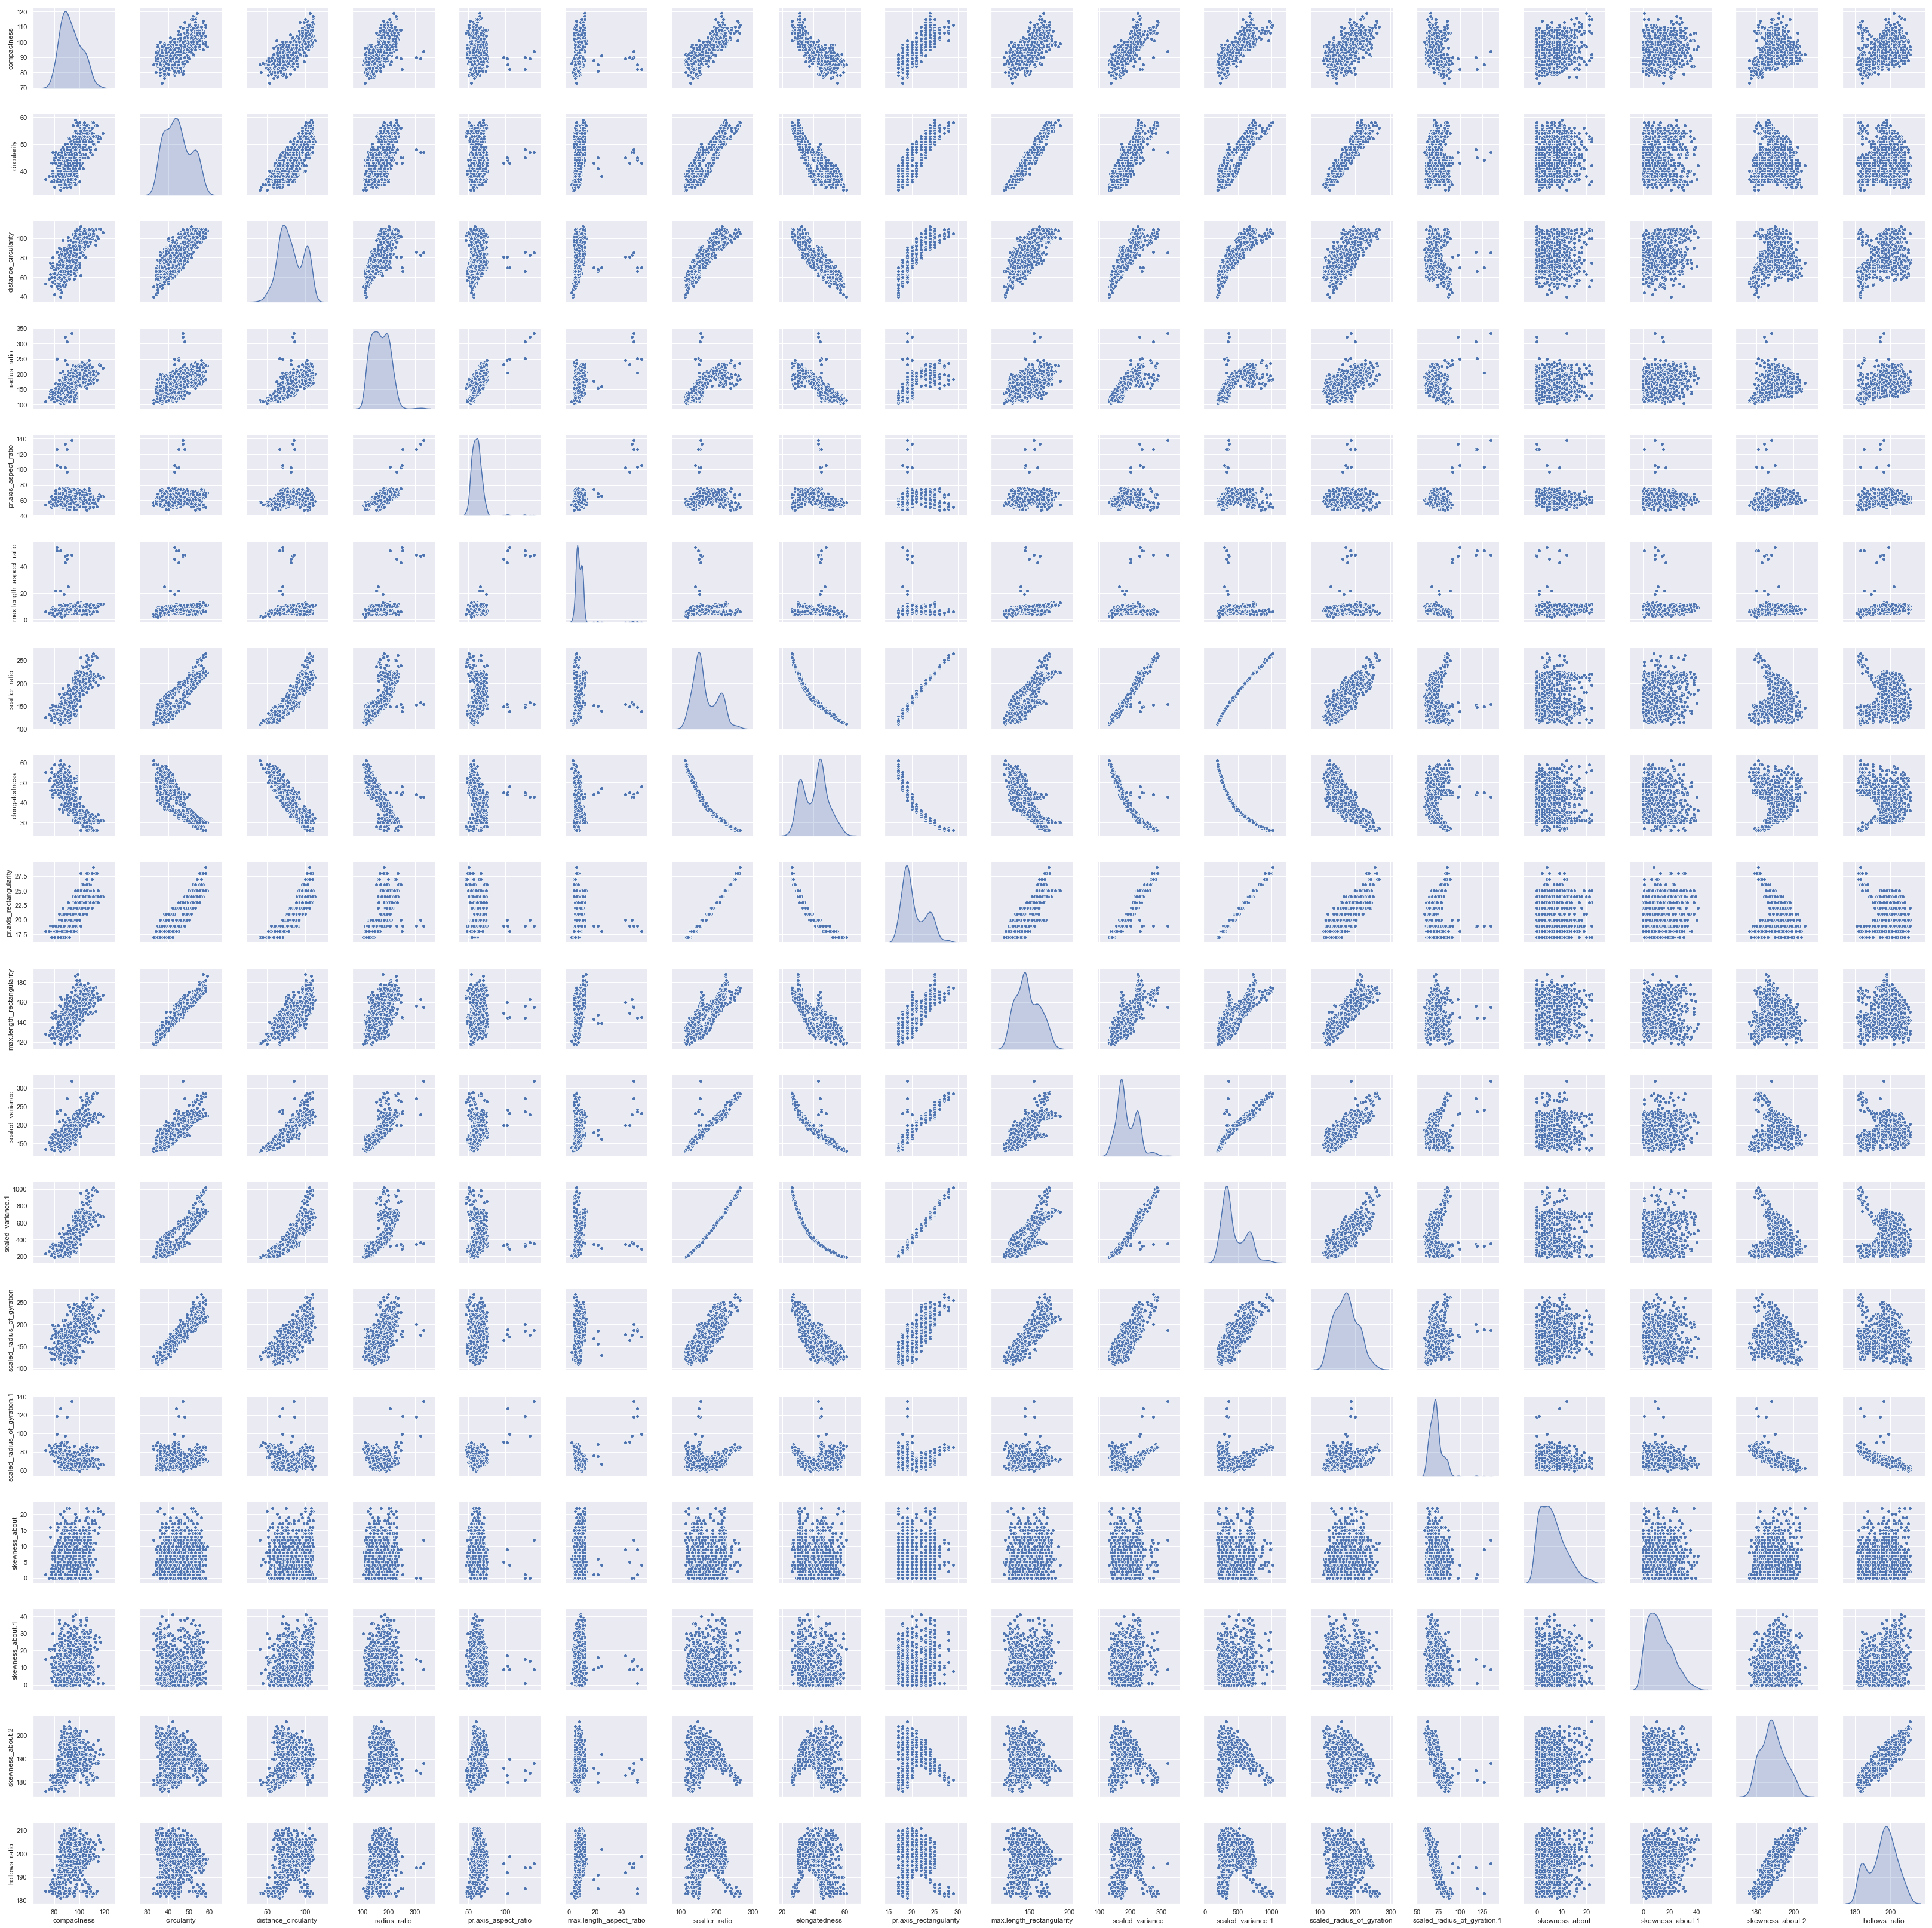

In [38]:
sns.pairplot(veh_df, diag_kind='kde')

### 4. Assign a dummy array called distortion

In [57]:
distortion =  []

You can later use this array to plot the elbow plot

In [41]:
from sklearn.cluster import KMeans

### 5. Calculating distortion - C distance

In [58]:
#Finding distrotion on Z values 
cluster_range = range( 1, 10) # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(veh_df_attr_Z)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  distortion.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "distortion": distortion } )
clusters_df[0:15]

,num_clusters,distortion
0,1,14634.000000
1,2,8623.136976
2,3,7037.467395
3,4,5739.201327
4,5,5189.588855
5,6,4707.860902
6,7,4410.264156
7,8,4084.251680
8,9,3848.165203


Iterating values of k from 1 to 10 fit K means model
Using c distance - Get the measure for Sum of squares error.

### 6. Plotting Elbow/ Scree Plot

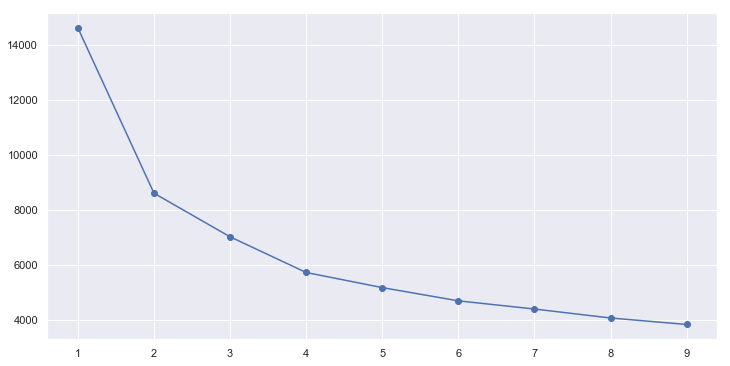

In [59]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.distortion, marker = "o" )

Use Matplotlib to plot the scree plot - Note: Scree plot plots distortion vs the no of clusters

### Find out the optimal value of K

In [77]:
cluster = KMeans( n_clusters = 5, random_state = 2354 )
cluster.fit(veh_df_attr_Z)
veh_df_attr_Z_copy = veh_df_attr_Z.copy(deep = True)

In [78]:
centroids = cluster.cluster_centers_
centroids

array([[-1.94233944e-01, -1.00497878e-02, -5.20338222e-03,
         2.81443455e-02,  1.99052327e-01, -2.48356410e-02,
        -1.69746365e-01, -4.57010900e-04, -2.07666510e-01,
         2.49659549e-02, -1.43210695e-01, -2.23553181e-01,
        -5.84105937e-03, -2.25869309e-01,  1.27785487e-02,
        -1.84785079e-01,  1.61245336e-01,  2.12079406e-01,
         4.00000000e+00],
       [-3.12150873e-01, -9.74388754e-01, -5.90466374e-01,
        -2.44738756e-01,  4.22757201e-02, -2.40152779e-01,
        -7.14840380e-01,  6.38036230e-01, -7.27247545e-01,
        -8.85696830e-01, -6.89185334e-01, -6.84004375e-01,
        -1.04692809e+00, -8.42395758e-01, -1.64809516e-01,
         1.14141139e-01,  1.15310883e+00,  9.45095130e-01,
         2.00000000e+00],
       [ 1.20502696e+00,  1.23168601e+00,  1.26049623e+00,
         9.79862160e-01,  7.40751051e-02,  2.40244838e-01,
         1.34856500e+00, -1.24468472e+00,  1.35927648e+00,
         1.15102932e+00,  1.24334585e+00,  1.36287899e+00,
    

In [72]:
centroid_df = pd.DataFrame(centroids, columns = list(veh_df_attr_Z) )
centroid_df

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,GROUP
0,-0.733024,0.072735,-0.272171,2.947683,6.836652,8.696706,-0.535008,0.466248,-0.557406,0.283411,1.697528,-0.588068,0.212701,4.965638,-0.274839,-0.231193,-0.707994,-0.453651,4.000000e+00
1,1.205027,1.231686,1.260496,0.979862,0.074075,0.240245,1.348565,-1.244685,1.359276,1.151029,1.243346,1.362879,1.135731,-0.092936,0.173975,0.285709,-0.037757,0.182499,1.000000e+00
2,-0.312151,-0.974389,-0.590466,-0.244739,0.042276,-0.240153,-0.714840,0.638036,-0.727248,-0.885697,-0.689185,-0.684004,-1.046928,-0.842396,-0.164810,0.114141,1.153109,0.945095,2.000000e+00
3,-1.014094,-0.686306,-1.059028,-1.184615,-0.637767,-0.431510,-0.869858,0.994003,-0.830279,-0.710132,-0.882047,-0.855239,-0.509194,0.911021,-0.075826,-0.256769,-1.133970,-1.293627,3.000000e+00
4,-0.194234,-0.010050,-0.005203,0.028144,0.199052,-0.024836,-0.169746,-0.000457,-0.207667,0.024966,-0.143211,-0.223553,-0.005841,-0.225869,0.012779,-0.184785,0.161245,0.212079,-4.440892e-16


In [73]:
prediction=cluster.predict(veh_df_attr_Z)
veh_df_attr_Z["GROUP"] = prediction 

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000179461C5BA8>,
      dtype=object)

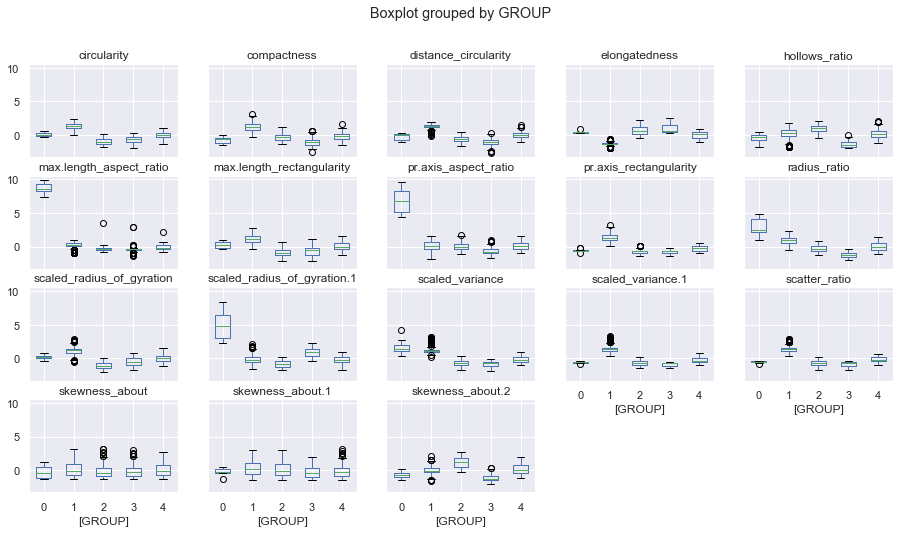

In [81]:
import matplotlib.pylab as plt

veh_df_attr_Z.boxplot(by = 'GROUP',  layout=(5,5), figsize=(15, 10))

### Using optimal value of K - Cluster the data. 
Note: Since the data has more than 2 dimension we cannot visualize the data. As an alternative, we can observe the centroids and note how they are distributed across different dimensions

#Initial a list to track SSE for KMeans with different K
sse_df = pd.DataFrame(columns=['K','SSE'])

for i in range(2,11):
    
    #Initialize KMeans
    km = KMeans(n_clusters=i, n_init=10, max_iter=300)
    
    #Fit on the data
    km.fit(veh_df_attr_Z)
    
    #Add cluster information for each record in dataframe
    veh_df_attr_Z['k_' + str(i)] = km.predict(veh_df_attr_Z)
    
    #Track K and SSE information in sse_df
    sse_df.loc[sse_df.shape[0]] = [i, km.inertia_]

### 7. Store the centroids in a dataframe with column names from the original dataset given 

In [82]:
centroid_df = pd.DataFrame(centroids, columns = list(veh_df_attr_Z) )
centroid_df

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,GROUP
0,-0.194234,-0.010050,-0.005203,0.028144,0.199052,-0.024836,-0.169746,-0.000457,-0.207667,0.024966,-0.143211,-0.223553,-0.005841,-0.225869,0.012779,-0.184785,0.161245,0.212079,4.000000e+00
1,-0.312151,-0.974389,-0.590466,-0.244739,0.042276,-0.240153,-0.714840,0.638036,-0.727248,-0.885697,-0.689185,-0.684004,-1.046928,-0.842396,-0.164810,0.114141,1.153109,0.945095,2.000000e+00
2,1.205027,1.231686,1.260496,0.979862,0.074075,0.240245,1.348565,-1.244685,1.359276,1.151029,1.243346,1.362879,1.135731,-0.092936,0.173975,0.285709,-0.037757,0.182499,1.000000e+00
3,-1.014094,-0.686306,-1.059028,-1.184615,-0.637767,-0.431510,-0.869858,0.994003,-0.830279,-0.710132,-0.882047,-0.855239,-0.509194,0.911021,-0.075826,-0.256769,-1.133970,-1.293627,3.000000e+00
4,-0.733024,0.072735,-0.272171,2.947683,6.836652,8.696706,-0.535008,0.466248,-0.557406,0.283411,1.697528,-0.588068,0.212701,4.965638,-0.274839,-0.231193,-0.707994,-0.453651,4.440892e-16


Hint: Use pd.Dataframe function 

### Use kmeans.labels_ function to print out the labels of the classes

In [84]:
print(cluster.labels_) 

[0 0 2 1 4 1 1 1 1 1 0 0 0 2 3 0 2 0 3 1 1 2 0 3 2 0 3 0 1 1 2 1 3 4 2 0 2
 3 0 1 2 0 3 3 0 0 3 1 2 1 2 1 0 0 2 3 2 3 3 3 0 3 2 0 2 2 0 3 0 2 0 3 0 2
 1 3 1 2 0 3 0 3 2 0 2 0 3 2 3 0 2 3 4 1 1 3 2 2 3 3 0 1 0 3 3 0 0 2 2 0 3
 0 1 1 0 0 3 3 0 2 2 1 0 3 2 4 0 1 3 0 1 2 3 0 2 0 1 1 1 2 0 1 2 0 2 1 3 1
 3 2 1 1 2 2 1 2 3 3 2 2 0 2 0 0 0 1 3 2 3 1 3 2 0 1 0 2 1 0 1 2 1 3 2 3 3
 3 0 1 2 2 1 0 0 3 2 1 1 1 2 3 3 2 3 1 2 0 3 3 1 2 1 2 3 3 3 3 2 1 0 1 2 3
 1 0 3 2 3 3 1 1 2 3 2 0 1 0 2 1 1 2 2 3 0 1 1 2 3 0 1 3 3 0 1 2 0 3 3 2 1
 0 3 3 2 3 1 2 3 1 4 0 1 2 1 2 3 0 1 2 0 1 1 3 0 2 2 2 0 0 0 2 3 3 3 0 3 2
 2 3 2 1 3 2 0 1 1 2 2 3 2 2 3 2 0 0 1 3 3 2 2 2 1 1 1 2 3 0 3 0 0 0 2 0 0
 2 2 0 0 0 2 0 3 3 0 0 0 0 3 2 2 3 3 2 3 2 3 2 0 0 0 0 4 2 3 1 0 0 0 0 0 1
 1 2 1 2 1 2 1 3 3 0 1 0 3 3 1 0 2 1 1 0 3 2 1 3 0 1 2 1 2 1 2 2 3 3 2 1 3
 3 0 2 2 0 1 2 2 0 2 2 2 1 0 1 1 1 2 3 3 0 2 1 1 2 0 3 0 3 3 2 1 0 2 2 2 3
 2 2 0 0 3 2 2 0 1 0 3 2 0 3 2 2 0 3 2 2 0 0 3 2 2 2 3 3 2 2 2 1 0 2 3 1 2
 1 3 3 1 2 3 1 0 3 4 2 0 

## Hierarchical Clustering 

### 8. Variable creation

For Hierarchical clustering, we will create datasets using multivariate normal distribution to visually observe how the clusters are formed at the end

In [99]:
a = np.random.multivariate_normal([10, 0], [[3, 1], [1, 4]], size=[100,])
b = np.random.multivariate_normal([0, 20], [[3, 1], [1, 4]], size=[50,])
c = np.random.multivariate_normal([10, 20], [[3, 1], [1, 4]], size=[100,])

array([[11.08339971, 19.97913079],
       [ 8.92432485, 20.00079681],
       [ 9.07854801, 20.0074024 ],
       [ 8.43593971, 19.87665396],
       [ 8.97404379, 15.7146198 ],
       [10.52794013, 20.73412015],
       [11.27372863, 24.70904973],
       [11.14716014, 18.27178036],
       [13.02733272, 21.94201775],
       [11.21615676, 18.15788938],
       [ 9.77392344, 15.43833889],
       [11.22093461, 17.60766723],
       [13.22248719, 20.17592884],
       [11.87247046, 18.88208203],
       [ 9.9289845 , 16.74221084],
       [10.85372325, 17.89149448],
       [13.67514746, 23.03705726],
       [11.7880124 , 19.76589123],
       [ 9.69206007, 23.07523649],
       [ 8.70290794, 18.11767668],
       [10.3745785 , 17.05206859],
       [ 9.97485109, 17.22895216],
       [ 8.41775652, 21.01861848],
       [10.29262164, 17.16912019],
       [ 5.79671854, 16.32465181],
       [ 7.45264707, 18.92863759],
       [12.14649414, 19.60605498],
       [10.80137759, 19.92997236],
       [11.9948601 ,

### 9. Combine all three arrays a,b,c into a dataframe

In [111]:
df_a = pd.DataFrame(a)
df_b = pd.DataFrame(b)
df_c = pd.DataFrame(c)
df = pd.concat([df_a,df_b,df_c])
df.head(3)

,0,1
0,12.548454,-0.029764
1,8.563266,0.871601
2,9.474607,1.271132


### 10. Use scatter matrix to print all the 3 distributions

C:\Users\sush\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: pandas.scatter_matrix is deprecated, use pandas.plotting.scatter_matrix instead
  """Entry point for launching an IPython kernel.


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000017949091DD8>,
      dtype=object)

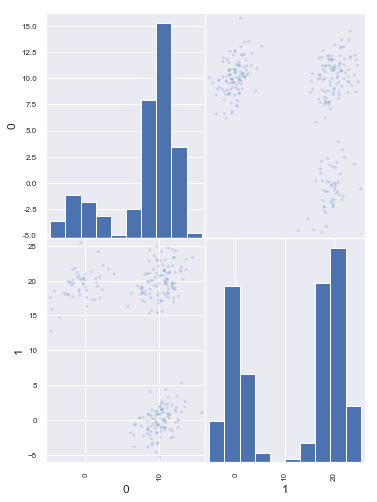

In [112]:
pd.scatter_matrix(df, alpha=0.2)

### 11. Find out the linkage matrix

Use ward as linkage metric and distance as Eucledian

In [114]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist  #Pairwise distribution between data points

In [155]:
from sklearn.cluster import AgglomerativeClustering 
model = AgglomerativeClustering(n_clusters=6, affinity='euclidean',  linkage='ward')
label = model.fit(df)

In [156]:
Z = linkage(df, 'ward',metric='euclidean')
c, coph_dists = cophenet(Z , pdist(df))
c

0.9520727509990745

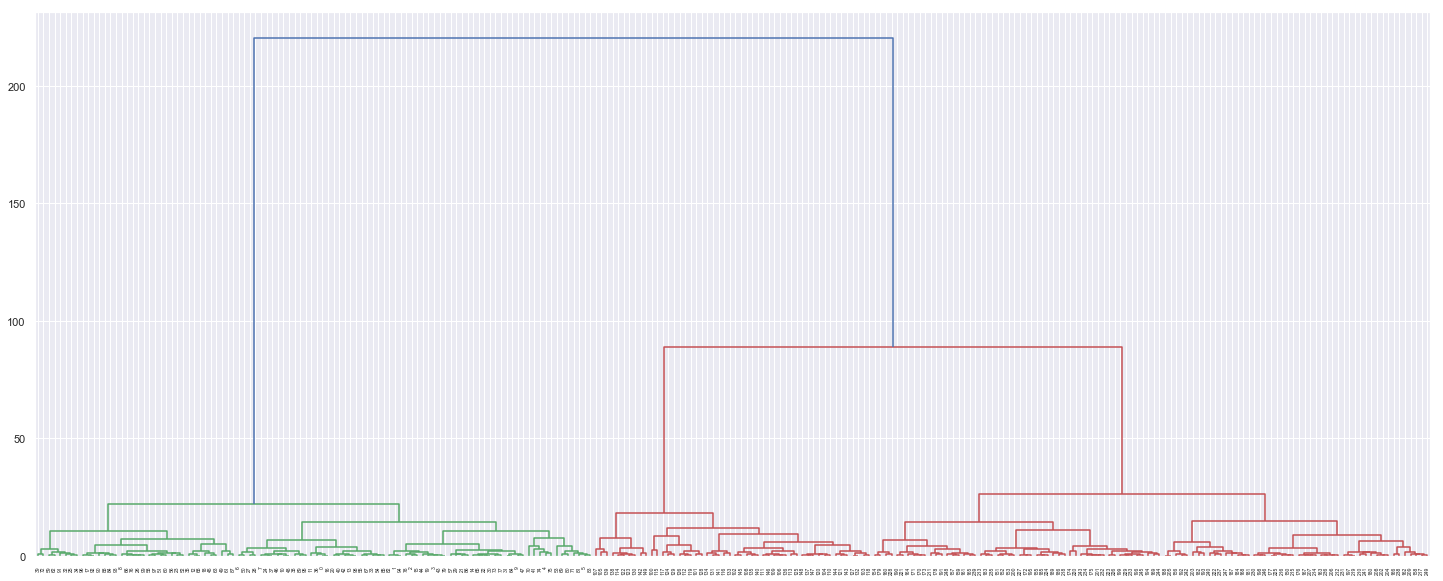

In [142]:
#Plotting thr linkage matrix
Z = linkage(df, 'ward',metric='euclidean')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)
plt.show()

### 12. Plot the dendrogram for the consolidated dataframe

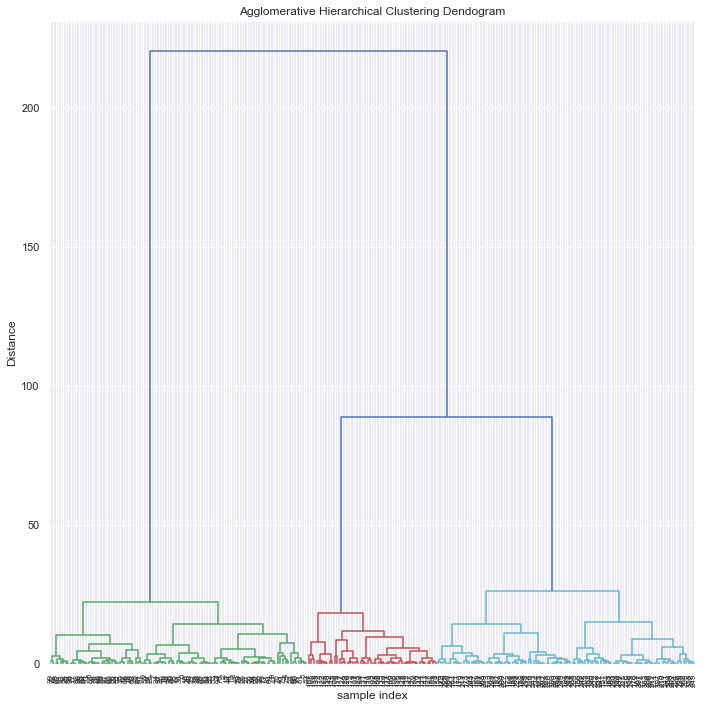

In [143]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 13. Recreate the dendrogram for last 12 merged clusters 

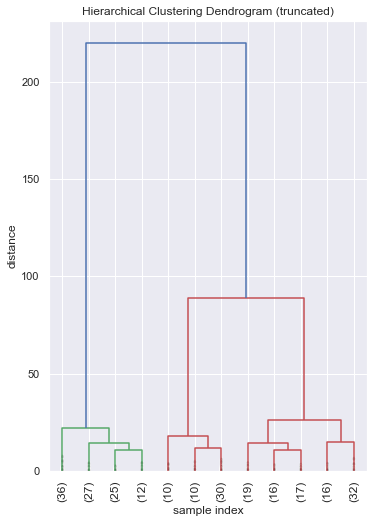

In [144]:
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,  # show only the last p merged clusters
    show_leaf_counts=True,  # otherwise numbers in brackets are counts
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

Hint: Use truncate_mode='lastp' attribute in dendrogram function to arrive at dendrogram 

### 14. From the truncated dendrogram, find out the optimal distance between clusters which u want to use an input for clustering data

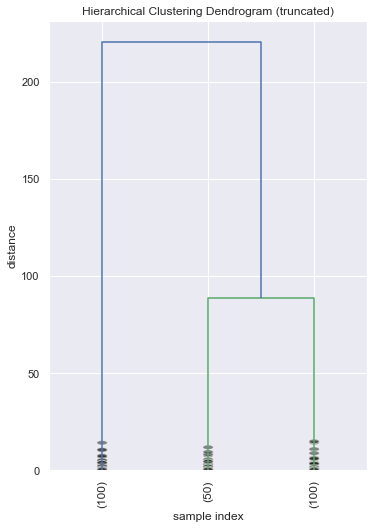

In [145]:
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=3,  # show only the last p merged clusters
    show_leaf_counts=True,  # otherwise numbers in brackets are counts
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

In [153]:
Z = linkage(df, 'ward',metric='euclidean')
c, coph_dists = cophenet(Z , pdist(df))
coph_dists

array([14.23708594, 14.23708594, 14.23708594, ..., 26.19891803,
       14.95255493, 26.19891803])

### 15. Using this distance measure and fcluster function to cluster the data into 3 different groups

In [146]:
from scipy.cluster.hierarchy import ward, fcluster
from scipy.spatial.distance import pdist

In [152]:
fcluster(Z, t=30, criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

In [159]:
df

,0,1
0,12.548454,-0.029764
1,8.563266,0.871601
2,9.474607,1.271132
3,10.026814,0.799092
4,12.404141,3.413569
5,12.286440,1.270259
6,11.926512,-2.408446
7,10.743547,-1.384609
8,9.499956,-1.099609
9,10.327100,2.363265


### Use matplotlib to visually observe the clusters in 2D space 

AttributeError: 'AgglomerativeClustering' object has no attribute 'cluster_centers_'

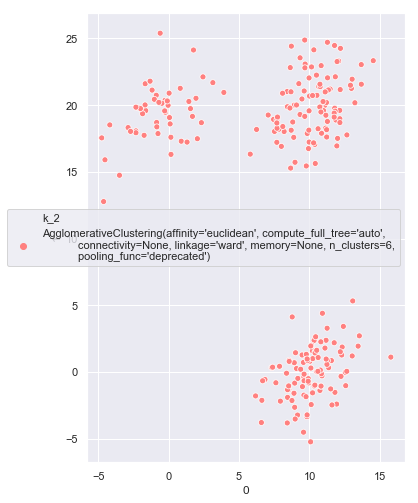

In [166]:
df['k_2'] = AgglomerativeClustering(n_clusters=6, affinity='euclidean',  linkage='ward')
sns.scatterplot(x=df.loc[:,0], y=df.loc[:,1], hue='k_2', data=df, palette='spring')
plt.scatter(model.cluster_centers_[:,1], model.cluster_centers_[:,2], s=100, marker='s', c='red', alpha=0.7, label='Centroids')